# Digit Recognition using Linear NN
not CNN :)

## High Level Workflow

### Training
- import training dataset - Images and Labels
- for each image serialize the pixels row-by-row into single long array of dim(28*28=784)
- 784x1 vector fed into input layer.
- let hidden layers h1 and h2 = e.g. 100 neurons
- activation function = ReLU


**NOTE**: for CNN we dont transform the image into 1D array, as it loses spatial information. There we use 2D mask...

For h1
- Weight Matrix = W (784x100)
- X = input (784x1)
- B = bias (100x1)
- Non_linear_activation(WX+B)

For h2
- W (100x100)
- X (100x1)
- B (100x1)
- Non_linear_activation(WX+B)

Output Layer
- Y = output (10x1) - 0 to 9 digit
- Sort by highest activation
- Pick top one

### Testing
- import testing dataset
- for each image run forward pass
- a = count of predicted label = actual label
- b = total datapoints
- Accuracy = (a/b)*100%
- confusion matrix visualisation

---

## 1. Training
### 1.1 Import and Read Dataset
The dataset is in `.idx3-ubyte` binary file format (the original dataset). And i dont wanna use any external libraries like `mlxtend` or something else.

$\therefore$ Use python's inbuilt struct module to pack and unpack binary data

**Little about struct package**: When you read a binary file, python sees it as a raw stream of 0s and 1s. The struct module acts as a "translator" that tells python how many bytes to grab and how to interpret them (take these 4 bytes and treat them as a single big-endian integer)

In [58]:
import struct
import numpy as np

# images
def read_images(path):
    with open(path,'rb') as imgs:
        # image file has 16 byte header
        # magic no.: 4 bytes
        # no. of Images: 4 bytes
        # rows: 4 bytes (28)
        # columns: 4 bytes (28)
        # skip them
        # '>' -> Big-Endian (standard for mnist), 'I' -> unsigned int
        magic, num, rows, cols = struct.unpack(">IIII", imgs.read(16))

        pixels = np.frombuffer(imgs.read(),dtype=np.uint8) # 0 to 255 -> 8 bit -> uint8
        pixels = pixels.reshape(num, rows, cols) # num images, each 28x28

    return pixels

#labels
def read_labels(path):
    with open(path,'rb') as l:
        # label file has 8 byte header
        # magic no. : 4 bytes
        # no. of items: 4 bytes
        magic, num = struct.unpack(">II", l.read(8))
        labels =np.frombuffer(l.read(),dtype=np.uint8)
    return labels

imgpath='mnist_dataset/train-images-idx3-ubyte'
labelPath='mnist_dataset/train-labels-idx1-ubyte'
x_train = read_images(imgpath)
y_train = read_labels(labelPath)

print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


### 1.2 Lets see some sample images :)

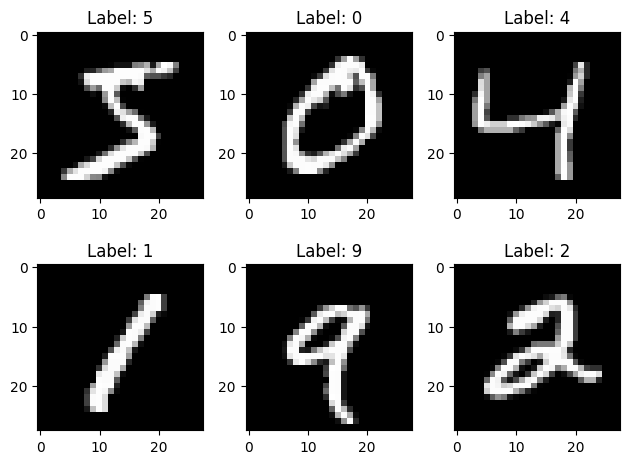

In [59]:
import matplotlib.pyplot as plt

sample_images = x_train[0:6]
sample_labels = y_train[0:6]
# print(sample_images[0].shape)
fig, axes = plt.subplots(2,3)

for j in range(axes.shape[0]):
    for i,ax in enumerate(axes[j]):
        ax.imshow(sample_images[i+(j*3)], cmap='gray')
        ax.set_title(f"Label: {sample_labels[i+(j*3)]}")

plt.tight_layout()
plt.show()

### 1.3 Actual training

Lets the actual training code begin :)

But before that some imp things:

We need mini-batching of dataset. Two Main reasons:

1. without batching its Pure Stochastic Gradient Descent (batch=1). We can't use GPU's parrallisation power as we are passing 1 sample at a time...

2. also as we pass 1 sample; the gradient updates are highly fluctuated in each iteration and loss may not reach proper global minima, because it gives noisy input in which a single bad sample will cause eratic weight updates and the gradient descnet direction may change drastically.

So we have to implement mini-batching by taking batch of size `b` and in each iteration; update weights on the basis of average loss , and also randomise the train dataset before making batches so that in a single batch of size `b` all images may never be all bad or noisy to cause the weight update eratic.

**NOTE**: dont confuse epoch with batch iteration. one epoch does weight updates for all the batches. epoch is number of times you wanna update weights for full dataset.

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1.4 Standardizing + Zero Centering
Before proceeding one importing thing: our gray scale numpy array has values from 0 to 255. Now this can causes difficulty for NN, because of several reasons and hence we need to NORMALIZE them to bring in [0,1].

1. **Prevents Gradient Instability**: Large, unscaled inputs generate massive gradients during backpropagation. This causes the optimizer to take chaotic, oversized steps, forcing you to use an impractically small learning rate just to prevent the network from diverging or outputting NaN values.

Also we need to zero-center the data because:

2. Data that isn't zero-centered (meaning all values are positive) creates an elongated, narrow ravine (a narrow deep valley with steep sides) in the mathematically defined loss landscape. The optimizer wastes epochs zig-zagging inefficiently across the walls of this ravine. Centering the data around zero makes the landscape more spherical, allowing the optimizer to step directly and quickly toward the global minimum.


$$x_{norm}=\frac{x_i-\bar{x}}{\sigma}$$

In [61]:
# Standardize
x_train=x_train/255.0

# zero center
x_mean = np.mean(x_train)
print("mean: ",x_mean)

std_dev=np.std(x_train)
print("std dev: ", std_dev)

x_train=(x_train-x_mean)/std_dev


mean:  0.1306604762738429
std dev:  0.3081078038564622


In [62]:
# need to convert to tensor
x_train=torch.from_numpy(x_train).float()
y_train=torch.from_numpy(y_train).long()
print(x_train.shape)
print(y_train.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


### 1.5 Mini-Batching

In [63]:
# data= list(zip(x_train,y_train)) # image,label
data = TensorDataset(x_train, y_train) # more memory efficient than above as creating list of tuples loads entire dataset into memory at once, while TensorDataset keeps the tensors separate in memory and only indexes them together on the fly when the DataLoader requests a batch

batch_size=50
shuffle=True


loader = DataLoader(data,batch_size,shuffle)


### 1.6 Model

Now comes model (NN)
custom model, not using built in NN
the class needs :
- `__init__`
- `forward` pass function

First using Sequential block without custom class.

In [64]:
NeuralNet=nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,1000),
    nn.ReLU(),
    nn.Linear(1000,1000),
    nn.ReLU(),
    nn.Linear(1000,1000),
    nn.ReLU(),
    nn.Linear(1000,10)
).to(device)
lossFxn=nn.CrossEntropyLoss()
# it penalizes the model more when it is confident about an incorrect class; less if it is less confident
lr=0.0001
optimiser=optim.Adam(NeuralNet.parameters(),lr=lr)

### 1.7 Training Loop

In [65]:
# training loop
epoch=50
losses=[]
for e in range(epoch):
    # batch wise
    NeuralNet.train()#set to training mode -> important when other layers like dropout,batchnorm are used :/
    global_loss=0.0
    for batch_x,batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        forward=NeuralNet(batch_x)
        loss=lossFxn(forward,batch_y)

        optimiser.zero_grad()
        loss.backward()
        global_loss+=loss.item()
        optimiser.step()

    losses.append(global_loss/len(loader))

    print(f"epoch: {e+1}, loss: {losses[-1]:.6f}")

epoch: 1, loss: 0.275749
epoch: 2, loss: 0.098103
epoch: 3, loss: 0.062559
epoch: 4, loss: 0.042299
epoch: 5, loss: 0.030630
epoch: 6, loss: 0.021971
epoch: 7, loss: 0.018296
epoch: 8, loss: 0.014631
epoch: 9, loss: 0.013368
epoch: 10, loss: 0.012165
epoch: 11, loss: 0.008612
epoch: 12, loss: 0.009408
epoch: 13, loss: 0.009300
epoch: 14, loss: 0.007984
epoch: 15, loss: 0.008469
epoch: 16, loss: 0.006058
epoch: 17, loss: 0.007236
epoch: 18, loss: 0.004656
epoch: 19, loss: 0.007218
epoch: 20, loss: 0.004749
epoch: 21, loss: 0.006484
epoch: 22, loss: 0.007201
epoch: 23, loss: 0.005018
epoch: 24, loss: 0.004158
epoch: 25, loss: 0.003837
epoch: 26, loss: 0.006173
epoch: 27, loss: 0.004424
epoch: 28, loss: 0.004326
epoch: 29, loss: 0.005420
epoch: 30, loss: 0.004672
epoch: 31, loss: 0.003864
epoch: 32, loss: 0.003049
epoch: 33, loss: 0.004786
epoch: 34, loss: 0.004267
epoch: 35, loss: 0.003861
epoch: 36, loss: 0.002879
epoch: 37, loss: 0.004681
epoch: 38, loss: 0.003272
epoch: 39, loss: 0.00

### 1.8 Loss Curve

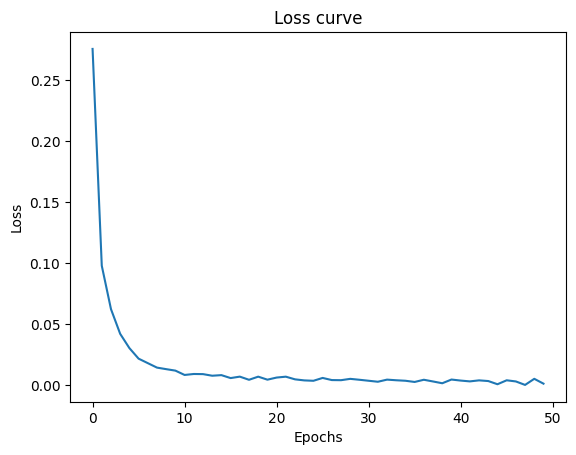

In [66]:
import os

model_type = "3_HL_NN_v5"
save_dir = f"models/{model_type}"
os.makedirs(save_dir, exist_ok=True)

#plot :)
ax=plt.subplot(1,1,1)
ax.plot(range(epoch),losses)
ax.set_title("Loss curve")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")

#save
plt.savefig(f"{save_dir}/loss_curve.png")
plt.show()

### 1.9 Archiving Weights and Checkpoint
 Save model weights and Checkpoint (other useful data)

In [67]:
checkpoint = {
    "model_state_dict": NeuralNet.state_dict(),
    "optimizer_state_dict": optimiser.state_dict(),
    "epochs": epoch,
    "train_mean": float(x_mean),
    "train_std": float(std_dev),
}
torch.save(checkpoint, f"{save_dir}/checkpoint.pth")

## 2. Testing

### 2.1 Accuracy

In [68]:
img_testPath='mnist_dataset/t10k-images-idx3-ubyte'
label_testPath='mnist_dataset/t10k-labels-idx1-ubyte'

x_test=read_images(img_testPath)
y_test=read_labels(label_testPath)

x_test=x_test/255.0

x_test=(x_test-x_mean)/std_dev # dont calc mean and stddev from test set, because our model is trained on coordinate system defined by the mean and stddev of training set not test set, they are now universal truth coordinate system!


x_test=torch.from_numpy(x_test).float().to(device)
y_test=torch.from_numpy(y_test).long().to(device)


def test(images, labels):
    NeuralNet.eval()
    with torch.no_grad():
        output = NeuralNet(images)
        pred = torch.argmax(output, dim=1)
        print(pred.shape)
        correct = (pred == labels).sum().item()
        acc = 100.0 * correct / labels.shape[0]
    return pred, acc

test_pred_labels, testAcc = test(x_test,y_test)
print("Test Accuracy = ", testAcc)

train_pred_labels,trainAcc = test(x_train.to(device),y_train.to(device))
print("Train Accuracy = ", trainAcc)

torch.Size([10000])
Test Accuracy =  98.32
torch.Size([60000])
Train Accuracy =  99.915


In [69]:
import json
with open(f"{save_dir}/metadata.json", "w") as f:
    json.dump({
        "model_type": model_type,
        "test_accuracy": testAcc,
        "train_accuracy": trainAcc,
        "final_train_loss": losses[-1],
        "epochs": epoch,
        "batch_size": batch_size,
        "learning_rate": lr,
        "optimizer": "Adam",
    }, f, indent=4)

### 2.2 Confusion Matrix

It helps in visualising which class the model is consistently predicting wrong - confusing it with other class.
> Confusion matrix, also known as error matrix, is a specific table layout that allows visualization of the performance of an algorithm, typically a supervised learning one. In unsupervised learning it is usually called a matching matrix. The term is used specifically in the problem of statistical classification. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa – both variants are found in the literature.

So diagonal = correctly predicted instance.

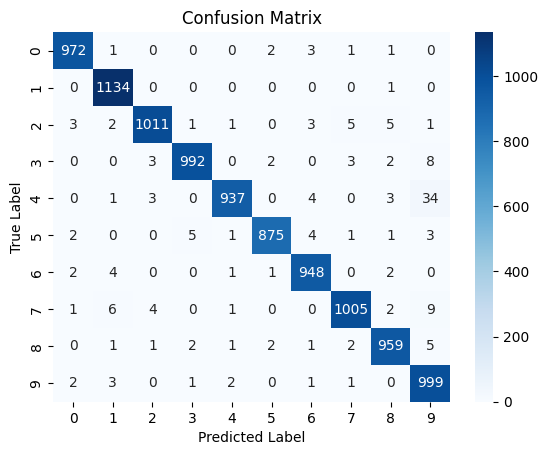

In [72]:
import seaborn as sns

conf_mat=np.zeros((10,10), dtype=int)
for t, p in zip(y_test, test_pred_labels):
    conf_mat[t][p] += 1
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

#save
plt.savefig(f"{save_dir}/confusion_matrix.png")
plt.show()

## 3. Prediction

In [ ]:
def predict(image, label, model, modelPath):
    checkpoint=torch.load(modelPath)
    #load model weights
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    model.to(device)

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)          # (1, 28, 28)
        output = model(image)               # logits shape= (1, 10)
        pred = torch.argmax(output, dim=1).item()

    # print("logits:", output)
    print("predicted label = ", pred)
    print("actual label = ", label.item())
    return pred

architectures={
    "2_HL_NN_v1": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
    ),
    "2_HL_NN_v2": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
     "2_HL_NN_v3": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
     "2_HL_NN_v4": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
     "2_HL_NN_v5": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
    "2_HL_NN_v6": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
    "2_HL_NN_v7": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
    "3_HL_NN_v1": lambda: nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,50),
        nn.ReLU(),
        nn.Linear(50,10)
     ),
    "3_HL_NN_v2": lambda:nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,50),
        nn.Sigmoid(),
        nn.Linear(50,50),
        nn.Sigmoid(),
        nn.Linear(50,50),
        nn.Sigmoid(),
        nn.Linear(50,10)
    ),
    "3_HL_NN_v3": lambda:nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,10),
        nn.ReLU(),
        nn.Linear(10,10),
        nn.ReLU(),
        nn.Linear(10,10),
        nn.ReLU(),
        nn.Linear(10,10)
    ),
    "3_HL_NN_v4": lambda:nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,100),
        nn.ReLU(),
        nn.Linear(100,100),
        nn.ReLU(),
        nn.Linear(100,100),
        nn.ReLU(),
        nn.Linear(100,10)
    ),
    "3_HL_NN_v5": lambda:nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,1000),
        nn.ReLU(),
        nn.Linear(1000,1000),
        nn.ReLU(),
        nn.Linear(1000,1000),
        nn.ReLU(),
        nn.Linear(1000,10)
    ),
}

model_path=f"models/{model_type}/checkpoint.pth"

model = architectures[model_type]()

predict(x_train[1010], y_train[1010], model, model_path)

predicted label =  2
actual label =  2


2